# **Proyecto de Modelos**

- Estefania Loaiza Salgado CC 1054857537
- Mariana Vasquez Ramirez CC 1027800363

## **Identificación del sistema respiratorio durante sueño normal**

Se modela la relación dinámica entre el flujo respiratorio, entrada `u(k)`, y el esfuerzo respiratorio, salida `y(k)`, usando el archivo `Exp15.csv`.

## **0. Carga y separación de señales**

Se usan las señales del inicio de la noche para estimación (`t1`, `u1`, `y1`) y las señales de validación (`tv`, `uv`, `yv`) para soportar la elección del modelo.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt, welch

data = pd.read_csv("Exp15.csv", header=None)
datos = data.iloc[1, :].astype(float).values

N = 30720

t1 = datos[0:N]
u1 = datos[N:2*N]
y1 = datos[2*N:3*N]

tv = datos[3*N:4*N]
uv = datos[4*N:5*N]
yv = datos[5*N:6*N]

t2 = datos[6*N:7*N]
u2 = datos[7*N:8*N]
y2 = datos[8*N:9*N]

Ts = np.mean(np.diff(t1))
fs = 1 / Ts

print("Ts =", Ts)
print("fs =", fs)
print("Muestras por segmento =", N)

Ts = 0.0009765625
fs = 1024.0
Muestras por segmento = 30720


## **1. Inspección inicial de las señales**

La respiración normal durante el sueño es principalmente periódica y de baja frecuencia. Se inspeccionan las señales antes del preprocesamiento.

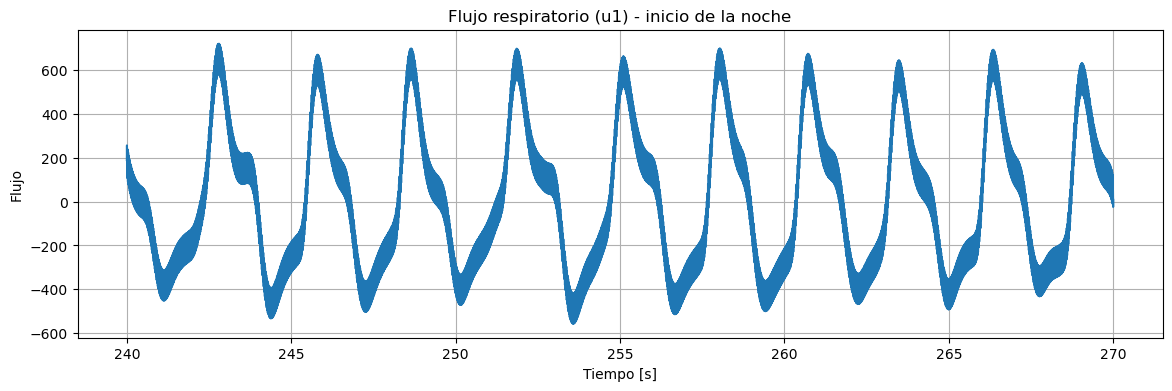

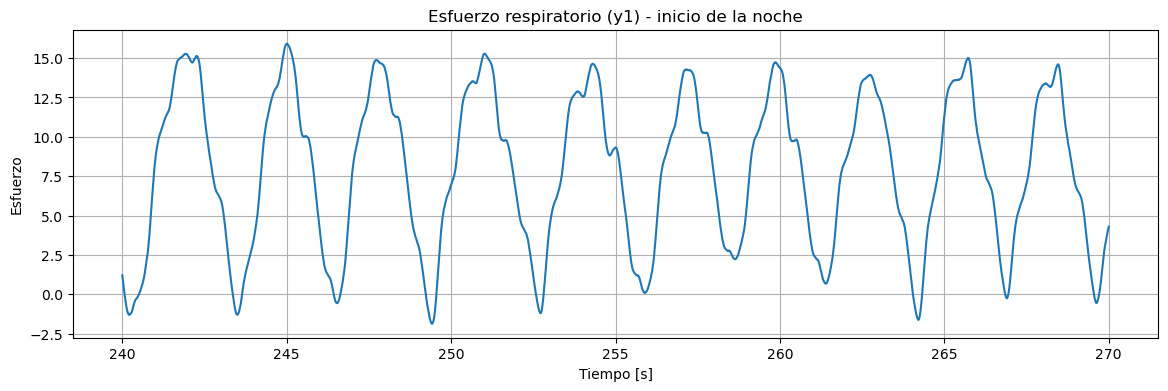

In [36]:
plt.figure(figsize=(14, 4))
plt.plot(t1, u1)
plt.title("Flujo respiratorio (u1) - inicio de la noche")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo")
plt.grid()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t1, y1)
plt.title("Esfuerzo respiratorio (y1) - inicio de la noche")
plt.xlabel("Tiempo [s]")
plt.ylabel("Esfuerzo")
plt.grid()
plt.show()

**Observaciones**

- El flujo `u1` y el esfuerzo `y1` son señales periódicas respiratorias claras.
- El esfuerzo presenta un ligero retardo respecto al flujo (esperable fisiológicamente).
- No se observan saturaciones ni discontinuidades.
- La frecuencia respiratoria es cercana a 0.3–0.4 Hz.

## **2. Preprocesamiento**

Se aplica el preprocesamiento requerido en la **consideración a)**:

- **Detrend:** elimina tendencias lentas no asociadas con la dinámica respiratoria local.
- **Filtrado pasa bajas:** `fc = 3 Hz`, para conservar la banda respiratoria dominante (justificado con la PSD).
- **Submuestreo:** se reduce la frecuencia de muestreo de `1024 Hz` a `32 Hz` usando `factor = 32`. Esta frecuencia sigue siendo mayor que el doble de la frecuencia de corte y evita que la predicción sea trivial por sobremuestreo.
- **Normalización:** con media y desviación estándar del conjunto de estimación; la misma escala se aplica a validación.

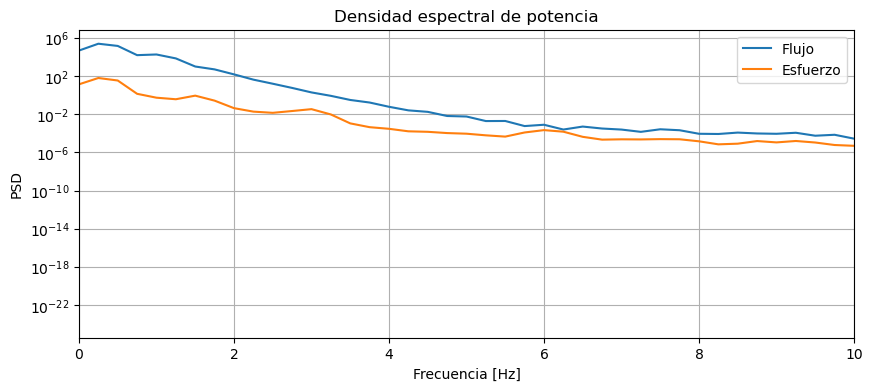

In [37]:
# Detrend
u1_d = detrend(u1)
y1_d = detrend(y1)
uv_d = detrend(uv)
yv_d = detrend(yv)

# Densidad espectral para justificar el filtrado
f_u, P_u = welch(u1_d, fs, nperseg=4096)
f_y, P_y = welch(y1_d, fs, nperseg=4096)

plt.figure(figsize=(10, 4))
plt.semilogy(f_u, P_u, label="Flujo")
plt.semilogy(f_y, P_y, label="Esfuerzo")
plt.xlim([0, 10])
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Densidad espectral de potencia")
plt.grid()
plt.legend()
plt.show()

In [38]:
# Filtrado pasa bajas
fc = 3
b_f, a_f = butter(4, fc / (fs / 2), btype="low")

u1_f = filtfilt(b_f, a_f, u1_d)
y1_f = filtfilt(b_f, a_f, y1_d)
uv_f = filtfilt(b_f, a_f, uv_d)
yv_f = filtfilt(b_f, a_f, yv_d)

# Submuestreo
factor = 32
u1_s = u1_f[::factor]
y1_s = y1_f[::factor]
uv_s = uv_f[::factor]
yv_s = yv_f[::factor]
fs_new = fs / factor

# Normalizacion con estadisticos del conjunto de estimacion
u_mean, u_std = np.mean(u1_s), np.std(u1_s)
y_mean, y_std = np.mean(y1_s), np.std(y1_s)

u1_n = (u1_s - u_mean) / u_std
y1_n = (y1_s - y_mean) / y_std
uv_n = (uv_s - u_mean) / u_std
yv_n = (yv_s - y_mean) / y_std

print("Nueva frecuencia de muestreo =", fs_new, "Hz")
print("Muestras estimacion =", len(u1_n))
print("Muestras validacion =", len(uv_n))

Nueva frecuencia de muestreo = 32.0 Hz
Muestras estimacion = 960
Muestras validacion = 960


# **Actividad 1. Identificación del sistema usando técnicas paramétricas**

Se estiman los modelos usando las señales del inicio de la noche (`u1_n`, `y1_n`) y se validan con (`uv_n`, `yv_n`).

Estructuras consideradas:

$$A(q)\,y(k)=e(k) \qquad \text{AR}$$

$$A(q)\,y(k)=B(q)\,u(k)+e(k) \qquad \text{ARX}$$

$$A(q)\,y(k)=C(q)\,e(k) \qquad \text{ARMA}$$

$$A(q)\,y(k)=B(q)\,u(k)+C(q)\,e(k) \qquad \text{ARMAX}$$

$$y(k)=\dfrac{B(q)}{F(q)}\,u(k)+e(k) \qquad \text{OE}$$

$$y(k)=\dfrac{B(q)}{F(q)}\,u(k)+\dfrac{C(q)}{D(q)}\,e(k) \qquad \text{BJ}$$

con

$$A(q)=1+a_1 q^{-1}+\cdots+a_{n_a} q^{-n_a}, \qquad B(q)=b_1 q^{-n_k}+\cdots+b_{n_b} q^{-(n_k+n_b-1)}$$

**Consideración b)** Se eligen órdenes con más de 4 parámetros. Para las estructuras con entrada se usan 6 retardos de salida y 6 de entrada.

## **Funciones auxiliares de identificación**

Funciones para construir regresores, estimar por mínimos cuadrados, predecir (un paso) y simular (salida libre), con las métricas `Fit [%]` y `RMSE`.

In [39]:
def fit_porcentaje(y_real, y_est):
    y_real = np.asarray(y_real).ravel()
    y_est = np.asarray(y_est).ravel()
    mask = np.isfinite(y_est)
    y_real = y_real[mask]
    y_est = y_est[mask]
    return 100 * (1 - np.linalg.norm(y_real - y_est) / np.linalg.norm(y_real - np.mean(y_real)))


def rmse(y_real, y_est):
    y_real = np.asarray(y_real).ravel()
    y_est = np.asarray(y_est).ravel()
    mask = np.isfinite(y_est)
    return np.sqrt(np.mean((y_real[mask] - y_est[mask]) ** 2))


def matriz_regresion(y, u, na, nb, nk, nc=0, e=None):
    inicio = max(na, nb + nk - 1 if nb > 0 else 0, nc)
    Phi, Y = [], []
    for k in range(inicio, len(y)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        if nc > 0 and e is not None:
            for i in range(1, nc + 1):
                fila.append(e[k - i])
        Phi.append(fila)
        Y.append(y[k])
    return np.asarray(Phi), np.asarray(Y), inicio


def predecir_modelo(y, u, theta, na, nb, nk, nc=0):
    y_est = np.full(len(y), np.nan)
    if nc > 0:
        theta_base = theta[:na + nb]
        y_base = predecir_modelo(y, u, theta_base, na, nb, nk, 0)
        e = y - y_base
        e[~np.isfinite(e)] = 0
    else:
        e = None
    _, _, inicio = matriz_regresion(y, u, na, nb, nk, nc, e)
    for k in range(inicio, len(y)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        if nc > 0:
            for i in range(1, nc + 1):
                fila.append(e[k - i])
        y_est[k] = np.dot(fila, theta)
    return y_est


def estimar_modelo(y, u, na, nb, nk, nc=0):
    Phi, Y, _ = matriz_regresion(y, u, na, nb, nk)
    theta_base = np.linalg.lstsq(Phi, Y, rcond=None)[0]
    if nc == 0:
        return theta_base
    y_base = predecir_modelo(y, u, theta_base, na, nb, nk, 0)
    e_base = y - y_base
    e_base[~np.isfinite(e_base)] = 0
    Phi, Y, _ = matriz_regresion(y, u, na, nb, nk, nc, e_base)
    return np.linalg.lstsq(Phi, Y, rcond=None)[0]


def simular_modelo(u, y_inicial, theta, na, nb, nk):
    y_sim = np.zeros(len(u))
    inicio = max(na, nb + nk - 1 if nb > 0 else 0)
    y_sim[:inicio] = y_inicial[:inicio]
    for k in range(inicio, len(u)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y_sim[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        y_sim[k] = np.dot(fila, theta[:na + nb])
    return y_sim

## **Estimación y validación de todas las estructuras**

Cada estructura se estima con los datos del inicio de la noche y se evalúa sobre las señales de validación, comparando `Fit [%]` y `RMSE`.

In [40]:
estructuras = [
    {"Estructura": "AR", "na": 6, "nb": 0, "nk": 1, "nc": 0},
    {"Estructura": "ARX", "na": 6, "nb": 6, "nk": 1, "nc": 0},
    {"Estructura": "ARMA", "na": 6, "nb": 0, "nk": 1, "nc": 3},
    {"Estructura": "ARMAX", "na": 6, "nb": 6, "nk": 1, "nc": 3},
    {"Estructura": "OE", "na": 6, "nb": 6, "nk": 1, "nc": 0},
    {"Estructura": "BJ", "na": 6, "nb": 6, "nk": 1, "nc": 3},
]

resultados = []
modelos_estimados = {}

for cfg in estructuras:
    nombre, na, nb, nk, nc = cfg["Estructura"], cfg["na"], cfg["nb"], cfg["nk"], cfg["nc"]

    u_est = np.zeros_like(u1_n) if nb == 0 else u1_n
    u_val = np.zeros_like(uv_n) if nb == 0 else uv_n

    theta = estimar_modelo(y1_n, u_est, na, nb, nk, nc)
    y_pred_val = predecir_modelo(yv_n, u_val, theta, na, nb, nk, nc)
    y_sim_val = simular_modelo(u_val, yv_n, theta, na, nb, nk)

    resultados.append({
        "Estructura": nombre,
        "Orden": f"na={na}, nb={nb}, nk={nk}, nc={nc}",
        "Parametros": len(theta),
        "Tiene entrada": nb > 0,
        "Fit prediccion [%]": fit_porcentaje(yv_n, y_pred_val),
        "Fit simulacion [%]": fit_porcentaje(yv_n, y_sim_val),
        "RMSE prediccion": rmse(yv_n, y_pred_val),
        "RMSE simulacion": rmse(yv_n, y_sim_val),
    })

    modelos_estimados[nombre] = {
        "theta": theta,
        "na": na,
        "nb": nb,
        "nk": nk,
        "nc": nc,
        "u_val": u_val,
        "y_pred_val": y_pred_val,
        "y_sim_val": y_sim_val,
    }

resultados_df = pd.DataFrame(resultados)

# Para describir la relacion flujo-esfuerzo se priorizan modelos con entrada.
# La seleccion se hace principalmente por simulacion libre en validacion,
# porque esta metrica evalua mejor la dinamica entrada-salida.
candidatos = resultados_df[resultados_df["Tiene entrada"]].copy()
candidatos = candidatos.sort_values(
    ["Fit simulacion [%]", "RMSE simulacion", "Fit prediccion [%]"],
    ascending=[False, True, False]
).reset_index(drop=True)

resultados_df = resultados_df.sort_values(
    ["Tiene entrada", "Fit simulacion [%]", "RMSE simulacion", "Fit prediccion [%]"],
    ascending=[False, False, True, False]
).reset_index(drop=True)

print("Comparacion de todas las estructuras:")
display(resultados_df)

print("Candidatos con entrada usados para seleccionar el modelo flujo-esfuerzo:")
display(candidatos)

Comparacion de todas las estructuras:


,Estructura,Orden,Parametros,Tiene entrada,Fit prediccion [%],Fit simulacion [%],RMSE prediccion,RMSE simulacion
0,ARMAX,"na=6, nb=6, nk=1, nc=3",15,True,99.997809,26.063557,0.000022,0.730631
1,BJ,"na=6, nb=6, nk=1, nc=3",15,True,99.997809,26.063557,0.000022,0.730631
2,ARX,"na=6, nb=6, nk=1, nc=0",12,True,99.991616,18.013998,0.000083,0.810176
3,OE,"na=6, nb=6, nk=1, nc=0",12,True,99.991616,18.013998,0.000083,0.810176
4,ARMA,"na=6, nb=0, nk=1, nc=3",9,False,99.998167,12.782775,0.000018,0.861871
5,AR,"na=6, nb=0, nk=1, nc=0",6,False,99.991502,10.712596,0.000084,0.882328


Candidatos con entrada usados para seleccionar el modelo flujo-esfuerzo:


,Estructura,Orden,Parametros,Tiene entrada,Fit prediccion [%],Fit simulacion [%],RMSE prediccion,RMSE simulacion
0,ARMAX,"na=6, nb=6, nk=1, nc=3",15,True,99.997809,26.063557,0.000022,0.730631
1,BJ,"na=6, nb=6, nk=1, nc=3",15,True,99.997809,26.063557,0.000022,0.730631
2,ARX,"na=6, nb=6, nk=1, nc=0",12,True,99.991616,18.013998,0.000083,0.810176
3,OE,"na=6, nb=6, nk=1, nc=0",12,True,99.991616,18.013998,0.000083,0.810176


Estructura seleccionada: ARMAX
Orden seleccionado: na=6, nb=6, nk=1, nc=3
Numero de parametros: 15
Fit prediccion [%]: 99.99780945749463
RMSE prediccion: 2.1684681932133603e-05
Fit simulacion [%]: 26.063557320361085
RMSE simulacion: 0.730631396579459


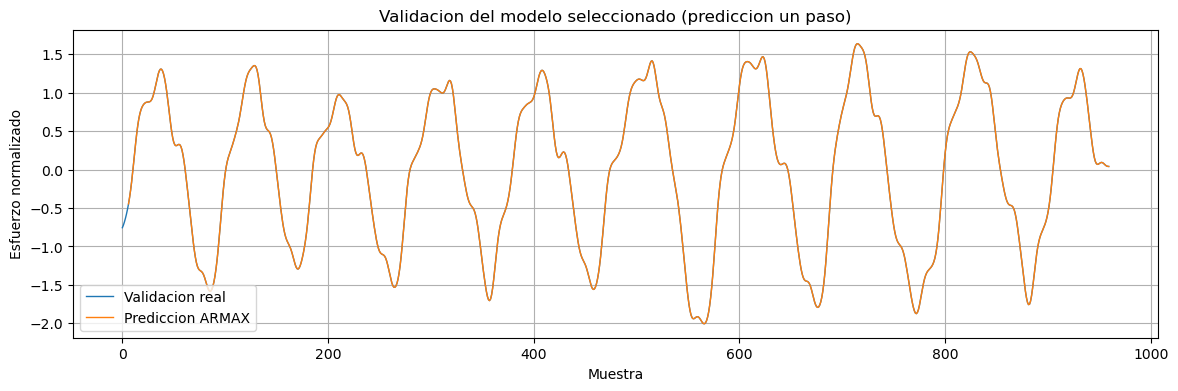

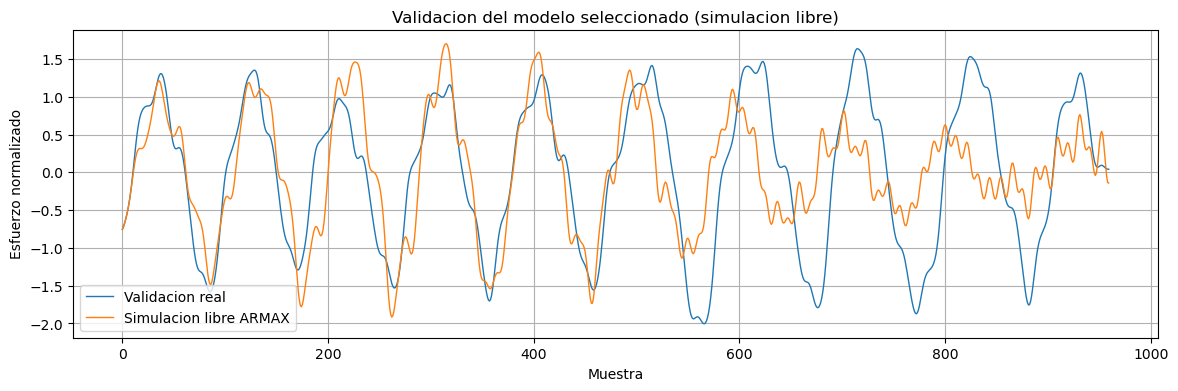

In [41]:
mejor_estructura = candidatos.iloc[0]["Estructura"]
modelo_final = modelos_estimados[mejor_estructura]

print("Estructura seleccionada:", mejor_estructura)
print("Orden seleccionado:", candidatos.iloc[0]["Orden"])
print("Numero de parametros:", candidatos.iloc[0]["Parametros"])
print("Fit prediccion [%]:", candidatos.iloc[0]["Fit prediccion [%]"])
print("RMSE prediccion:", candidatos.iloc[0]["RMSE prediccion"])
print("Fit simulacion [%]:", candidatos.iloc[0]["Fit simulacion [%]"])
print("RMSE simulacion:", candidatos.iloc[0]["RMSE simulacion"])

plt.figure(figsize=(14, 4))
plt.plot(yv_n, label="Validacion real", linewidth=1)
plt.plot(modelo_final["y_pred_val"], label=f"Prediccion {mejor_estructura}", linewidth=1)
plt.title("Validacion del modelo seleccionado (prediccion un paso)")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(yv_n, label="Validacion real", linewidth=1)
plt.plot(modelo_final["y_sim_val"], label=f"Simulacion libre {mejor_estructura}", linewidth=1)
plt.title("Validacion del modelo seleccionado (simulacion libre)")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

## **C. Ecuación final del modelo**

Se presenta el modelo seleccionado con sus coeficientes numéricos y su ecuación en diferencias, que describe la relación entre el flujo `u(k)` y el esfuerzo `y(k)` al inicio de la noche.

In [42]:
theta = modelo_final["theta"]
na, nb, nk = modelo_final["na"], modelo_final["nb"], modelo_final["nk"]

a_coef = theta[:na]
b_coef = theta[na:na + nb]

Aq = "1 " + " ".join([f"{a:+.6f} q^-{i}" for i, a in enumerate(a_coef, start=1)])
Bq = " ".join([f"{b:+.6f} q^-{nk + j}" for j, b in enumerate(b_coef)]) if nb > 0 else "0"

ecuacion_y = " ".join([f"{-a_coef[i - 1]:+.6f} y(k-{i})" for i in range(1, na + 1)])
ecuacion_u = " ".join([f"{b_coef[j]:+.6f} u(k-{nk + j})" for j in range(nb)])

print("Estructura seleccionada:", mejor_estructura)
print()
print("Modelo final (datos normalizados):")
print("A(q) y(k) = B(q) u(k) + e(k)")
print("A(q) =", Aq)
print("B(q) =", Bq)
print()
print("Ecuacion en diferencias:")
print("y(k) =", ecuacion_y, ecuacion_u, "+ e(k)")

Estructura seleccionada: ARMAX

Modelo final (datos normalizados):
A(q) y(k) = B(q) u(k) + e(k)
A(q) = 1 -5.573716 q^-1 +13.316768 q^-2 -17.465197 q^-3 +13.262366 q^-4 -5.526926 q^-5 +0.986846 q^-6
B(q) = -0.053848 q^-1 +0.333635 q^-2 -0.803682 q^-3 +0.951559 q^-4 -0.557346 q^-5 +0.129673 q^-6

Ecuacion en diferencias:
y(k) = +5.573716 y(k-1) -13.316768 y(k-2) +17.465197 y(k-3) -13.262366 y(k-4) +5.526926 y(k-5) -0.986846 y(k-6) -0.053848 u(k-1) +0.333635 u(k-2) -0.803682 u(k-3) +0.951559 u(k-4) -0.557346 u(k-5) +0.129673 u(k-6) + e(k)


## **Justificación de la selección**

La estructura se selecciona usando las señales de validación, pero priorizando los modelos que contienen entrada (`u(k)`), porque el objetivo del proyecto es describir la relación entre el flujo respiratorio y el esfuerzo respiratorio.

Aunque los modelos AR y ARMA pueden alcanzar buen desempeño en predicción de un paso, estos modelos dependen únicamente de valores pasados de la salida y no describen explícitamente la relación flujo-esfuerzo. Por esta razón, la comparación final se realiza entre ARX, ARMAX, OE y BJ.

La métrica principal de selección es el `Fit simulación [%]` junto con el `RMSE simulación`, porque la simulación libre evalúa mejor la dinámica entrada-salida del modelo en validación. También se reporta la predicción de un paso como soporte adicional.

El orden seleccionado cumple la **consideración b)** porque tiene más de 4 parámetros. Además, los retardos incluidos permiten capturar la memoria del sistema respiratorio y el desfase fisiológico entre el flujo y el esfuerzo al inicio de la noche.

# **Actividad 2. Análisis de sensibilidad**

Sobre el modelo final se analiza la sensibilidad de sus parámetros. Cada parámetro se perturba un 1% y se mide el cambio relativo que produce en la salida estimada durante validación:

$$
S_i = \frac{\lVert \hat{y}_{\theta_i + \Delta\theta_i} - \hat{y}_{\theta} \rVert_2}{\lVert \hat{y}_{\theta} \rVert_2}\,\frac{1}{\Delta}
$$

Los parámetros con mayor `S_i` son los más influyentes en la dinámica entrada-salida.

In [43]:
def nombres_parametros(na, nb, nk, nc):
    nombres = []
    for i in range(1, na + 1):
        nombres.append(f"a{i}")
    for j in range(nb):
        nombres.append(f"b{j + 1} (q^-{nk + j})")
    for i in range(1, nc + 1):
        nombres.append(f"c{i}")
    return nombres


def salida_sensibilidad(theta_eval):
    return predecir_modelo(
        yv_n, modelo_final["u_val"], theta_eval,
        modelo_final["na"], modelo_final["nb"], modelo_final["nk"], modelo_final["nc"],
    )


theta0 = modelo_final["theta"].copy()
y_base = salida_sensibilidad(theta0)
mask = np.isfinite(y_base)
perturbacion = 0.01
nombres = nombres_parametros(modelo_final["na"], modelo_final["nb"], modelo_final["nk"], modelo_final["nc"])

sensibilidades = []
for i in range(len(theta0)):
    theta_p = theta0.copy()
    delta = perturbacion * abs(theta0[i]) if abs(theta0[i]) > 1e-8 else perturbacion
    theta_p[i] += delta
    y_p = salida_sensibilidad(theta_p)
    s = (np.linalg.norm(y_p[mask] - y_base[mask]) / np.linalg.norm(y_base[mask])) / perturbacion
    sensibilidades.append({"Parametro": nombres[i], "Valor": theta0[i], "Sensibilidad": s})

sensibilidad_df = pd.DataFrame(sensibilidades).sort_values("Sensibilidad", ascending=False).reset_index(drop=True)
sensibilidad_df

,Parametro,Valor,Sensibilidad
0,a3,-17.465197,1.375578
1,a4,13.262366,1.061547
2,a2,13.316768,1.030295
3,a5,-5.526926,0.448530
4,a1,-5.573716,0.423084
5,a6,0.986846,0.080960
6,b4 (q^-4),0.951559,0.065667
7,b3 (q^-3),-0.803682,0.055980
8,b5 (q^-5),-0.557346,0.038513
9,b2 (q^-2),0.333635,0.023744


,Parametro,Valor,Sensibilidad
0,a3,-17.465197,1.375578
1,a4,13.262366,1.061547
2,a2,13.316768,1.030295
3,a5,-5.526926,0.448530


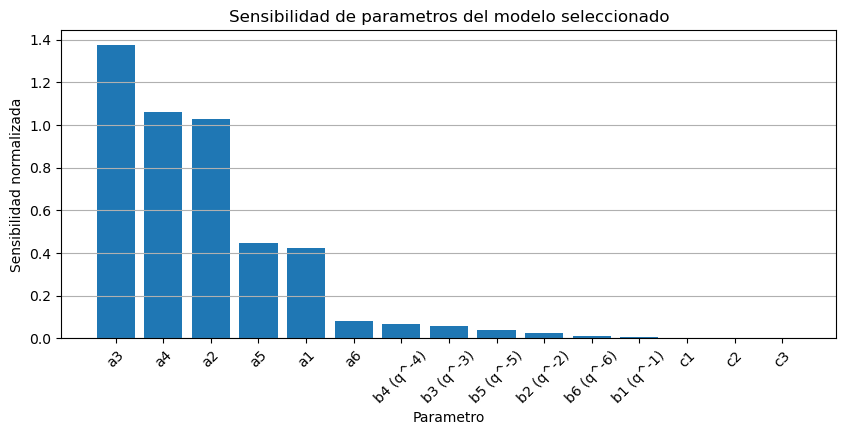

Los 4 parametros mas sensibles son:
a3: sensibilidad = 1.375578, valor = -17.465197
a4: sensibilidad = 1.061547, valor = 13.262366
a2: sensibilidad = 1.030295, valor = 13.316768
a5: sensibilidad = 0.448530, valor = -5.526926


In [44]:
top4_sensibles = sensibilidad_df.head(4)
display(top4_sensibles)

plt.figure(figsize=(10, 4))
plt.bar(sensibilidad_df["Parametro"], sensibilidad_df["Sensibilidad"])
plt.title("Sensibilidad de parametros del modelo seleccionado")
plt.xlabel("Parametro")
plt.ylabel("Sensibilidad normalizada")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

print("Los 4 parametros mas sensibles son:")
for _, fila in top4_sensibles.iterrows():
    print(f"{fila['Parametro']}: sensibilidad = {fila['Sensibilidad']:.6f}, valor = {fila['Valor']:.6f}")

## **Justificación de los 4 parámetros más sensibles**

Los cuatro parámetros seleccionados son los de mayor sensibilidad normalizada: pequeñas variaciones en ellos producen los mayores cambios en la salida estimada del esfuerzo respiratorio durante validación.

Por tanto, son los parámetros más influyentes del modelo final y deben estimarse con mayor cuidado, ya que errores en ellos afectan más la descripción de la relación entre flujo y esfuerzo. Los parámetros restantes tienen menor impacto, lo que indica que el modelo podría incluso simplificarse sin perder mucha precisión.

# **Actividad 3. Optimización**

Una vez identificada la estructura del modelo durante el inicio de la noche y determinado que los parámetros más sensibles son a2, a3, a4, a5 , se busca encontrar los valores de estos parámetros que mejor describen la dinámica respiratoria cuando el sujeto se encuentra en una etapa avanzada de sueño.

Para ello se mantiene fija la estructura ARMAX identificada en la Actividad 1 y únicamente se optimizan los cuatro parámetros más sensibles encontrados en la Actividad 2. De esta manera es posible analizar cómo cambia la dinámica del sistema respiratorio entre vigilia y sueño sin modificar la estructura matemática del modelo.

# 3.1 Preprocesamiento de las señales de sueño

Las señales registradas durante el sueño deben recibir exactamente el mismo tratamiento aplicado a las señales utilizadas en la identificación del modelo. Esto garantiza que las diferencias observadas se deban a cambios fisiológicos y no a diferencias en el procesamiento de los datos.

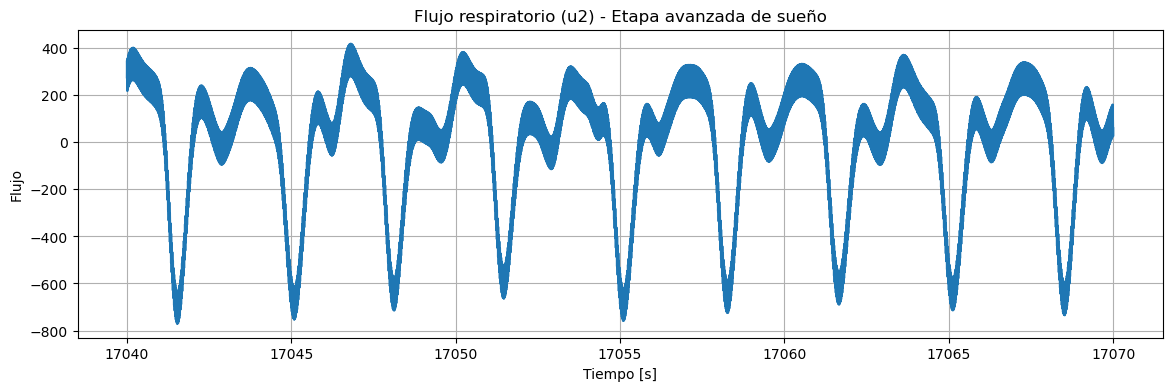

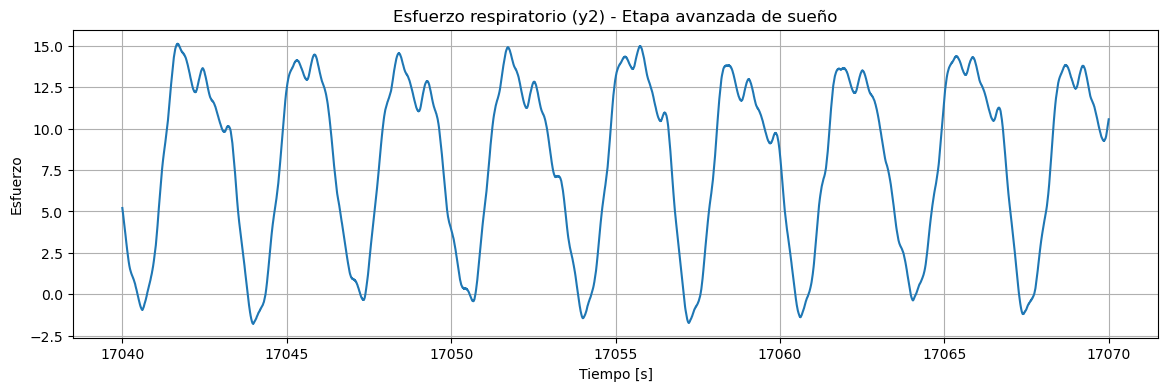

In [45]:
plt.figure(figsize=(14, 4))
plt.plot(t2, u2)
plt.title("Flujo respiratorio (u2) - Etapa avanzada de sueño")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo")
plt.grid()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t2, y2)
plt.title("Esfuerzo respiratorio (y2) - Etapa avanzada de sueño")
plt.xlabel("Tiempo [s]")
plt.ylabel("Esfuerzo")
plt.grid()
plt.show()

In [46]:
# PREPROCESAMIENTO DE LAS SEÑALES DE SUEÑO

# Eliminación de tendencias lentas
# Esto evita que componentes de muy baja frecuencia afecten
# la identificación de la dinámica respiratoria.

u2_d = detrend(u2)
y2_d = detrend(y2)

# Aplicación del mismo filtro pasa-bajas utilizado
# durante la etapa de identificación.
# Se conserva únicamente la banda respiratoria relevante.

u2_f = filtfilt(b_f, a_f, u2_d)
y2_f = filtfilt(b_f, a_f, y2_d)

# Submuestreo usando el mismo factor empleado anteriormente.
# Esto reduce la carga computacional sin perder información
# importante de la respiración.

u2_s = u2_f[::factor]
y2_s = y2_f[::factor]

# Normalización utilizando las estadísticas obtenidas
# del conjunto de identificación.
# Es importante NO recalcular media y desviación estándar,
# ya que se desea comparar ambos estados bajo la misma escala.

u2_n = (u2_s - u_mean) / u_std
y2_n = (y2_s - y_mean) / y_std

print("Número de muestras sueño:", len(u2_n))

Número de muestras sueño: 960


## 3.2 Selección de los parámetros a optimizar

**Justificación**

El análisis de sensibilidad mostró que los parámetros más influyentes sobre la salida del modelo fueron: a3, a4, a2, a5	​

Por lo tanto, únicamente estos parámetros serán ajustados durante la optimización. Los demás permanecerán constantes para conservar la estructura identificada en vigilia.

In [47]:
# PARAMETROS A OPTIMIZAR

# Copia de los parámetros identificados en vigilia

theta_base = modelo_final["theta"].copy()

# Generación de la lista de nombres para verificar
# el orden de los parámetros dentro del vector theta

nombres = nombres_parametros(
    modelo_final["na"],
    modelo_final["nb"],
    modelo_final["nk"],
    modelo_final["nc"]
)

print("Orden de parámetros en theta:\n")

for i, (nombre, valor) in enumerate(zip(nombres, theta_base)):
    print(f"Indice {i:2d} --> {nombre:10s} = {valor:.6f}")

Orden de parámetros en theta:

Indice  0 --> a1         = -5.573716
Indice  1 --> a2         = 13.316768
Indice  2 --> a3         = -17.465197
Indice  3 --> a4         = 13.262366
Indice  4 --> a5         = -5.526926
Indice  5 --> a6         = 0.986846
Indice  6 --> b1 (q^-1)  = -0.053848
Indice  7 --> b2 (q^-2)  = 0.333635
Indice  8 --> b3 (q^-3)  = -0.803682
Indice  9 --> b4 (q^-4)  = 0.951559
Indice 10 --> b5 (q^-5)  = -0.557346
Indice 11 --> b6 (q^-6)  = 0.129673
Indice 12 --> c1         = 2.213852
Indice 13 --> c2         = -2.007044
Indice 14 --> c3         = 0.732089


# **3.3 Definición de las semillas iniciales**

**Justificación de las semillas**

Los valores obtenidos durante la identificación del sistema en vigilia constituyen una elección adecuada para las semillas iniciales porque: provienen de un modelo previamente validado, describen el mismo sistema fisiológico, el sueño modifica la dinámica respiratoria, pero no cambia completamente la naturaleza del sistema.

Por esta razón, los valores identificados durante la vigilia se utilizan como punto de partida para la optimización.

In [48]:
# INDICES DE LOS PARAMETROS MAS SENSIBLES

# Ubicación de los parámetros sensibles dentro de theta

indices_opt = [2, 3, 1, 4]

# Extracción de los valores iniciales

theta0 = theta_base[indices_opt]

print("Semillas iniciales:")

for indice, valor in zip(indices_opt, theta0):
    print(f"{nombres[indice]} = {valor:.6f}")

Semillas iniciales:
a3 = -17.465197
a4 = 13.262366
a2 = 13.316768
a5 = -5.526926


# **3.4 Definición de la función de costo**

### **Función de costo**

La optimización busca minimizar el error cuadrático medio (MSE, *Mean Squared Error*) entre la salida real medida durante el sueño y la salida predicha por el modelo. De esta manera, los parámetros optimizados corresponden a aquellos que mejor reproducen la dinámica respiratoria observada en esta etapa.

La función de costo utilizada se define como:

$$
J(\theta)=\frac{1}{N}\sum_{k=1}^{N}
\left(y_{\text{real}}(k)-y_{\text{modelo}}(k)\right)^2
$$

donde:

- $J(\theta)$ es la función de costo a minimizar.
- $N$ es el número total de muestras utilizadas en la optimización.
- $y_{\text{real}}(k)$ corresponde al esfuerzo respiratorio medido durante el sueño.
- $y_{\text{modelo}}(k)$ corresponde a la salida estimada por el modelo para un conjunto dado de parámetros.
- $\theta$ representa el vector de parámetros optimizados.

La minimización de esta función permite encontrar los valores de los parámetros más sensibles ((a_2), (a_3), (a_4) y (a_5)) que producen la mejor aproximación entre el modelo y el comportamiento respiratorio observado durante el sueño avanzado.


In [66]:
from scipy.optimize import minimize

def funcion_costo(parametros_opt):

    theta_actual = theta_base.copy()

    theta_actual[indices_opt] = parametros_opt

    y_sim = simular_modelo(
        u2_n,
        y2_n,
        theta_actual,
        modelo_final["na"],
        modelo_final["nb"],
        modelo_final["nk"]
    )

    return np.mean(
        (y2_n - y_sim)**2
    )

# **3.5 Optimización de los parámetros**

Se utiliza el algoritmo Nelder-Mead, el cual no requiere el cálculo explícito de derivadas y es ampliamente utilizado para optimización de parámetros en modelos dinámicos.

In [ ]:
# OPTIMIZACION
# maxiter se ajusta para permitir suficiente exploración del espacio de parámetros
# disp=True habilita la impresión de cada iteración, lo que ayuda a monitorear el progreso
resultado = minimize(
    funcion_costo,
    theta0,
    method="Nelder-Mead",
    options={
        "maxiter": 1000,
        "disp": True
    }
)

print("\nOptimización finalizada")
print("Costo mínimo:", resultado.fun)

C:\Users\MARIANA\AppData\Local\Temp\ipykernel_29540\2720618537.py:19: RuntimeWarning: overflow encountered in square
  (y2_n - y_sim)**2


Optimization terminated successfully.
         Current function value: 0.225074
         Iterations: 141
         Function evaluations: 270

Optimización finalizada
Costo mínimo: 0.22507364823212814


# **3.6 Parámetros óptimos obtenidos**


In [68]:
# PARAMETROS OPTIMOS

theta_sueno = theta_base.copy()

theta_sueno[indices_opt] = resultado.x

print("Comparación vigilia vs sueño\n")

for idx in indices_opt:

    print(
        f"{nombres[idx]:5s} | "
        f"vigilia = {theta_base[idx]:10.6f} | "
        f"sueño = {theta_sueno[idx]:10.6f}"
    )

Comparación vigilia vs sueño

a3    | vigilia = -17.465197 | sueño = -17.471298
a4    | vigilia =  13.262366 | sueño =  13.263799
a2    | vigilia =  13.316768 | sueño =  13.320301
a5    | vigilia =  -5.526926 | sueño =  -5.525809


### **Análisis**

Se observa que las diferencias entre ambos estados son pequeñas, lo que indica que la relación dinámica entre el flujo respiratorio y el esfuerzo respiratorio permanece relativamente estable entre la vigilia y el sueño. Sin embargo, los cambios encontrados reflejan adaptaciones fisiológicas asociadas a la regulación respiratoria durante el sueño, donde existe una menor influencia de mecanismos voluntarios y un mayor predominio del control automático de la respiración.

La magnitud reducida de las variaciones también sugiere que la mecánica respiratoria del sujeto no experimentó alteraciones bruscas entre ambos registros, lo cual es consistente con una condición fisiológica normal y ausencia de trastornos respiratorios evidentes.

# **3.7 Métricas de desempeño**

In [52]:
# VALIDACION DEL MODELO OPTIMIZADO

y_sueno_pred = predecir_modelo(
    y2_n,
    u2_n,
    theta_sueno,
    modelo_final["na"],
    modelo_final["nb"],
    modelo_final["nk"],
    modelo_final["nc"]
)

fit_sueno = fit_porcentaje(y2_n, y_sueno_pred)
rmse_sueno = rmse(y2_n, y_sueno_pred)

print("FIT sueño [%] =", fit_sueno)
print("RMSE sueño =", rmse_sueno)

FIT sueño [%] = 99.99824514207045
RMSE sueño = 1.8451464216712037e-05


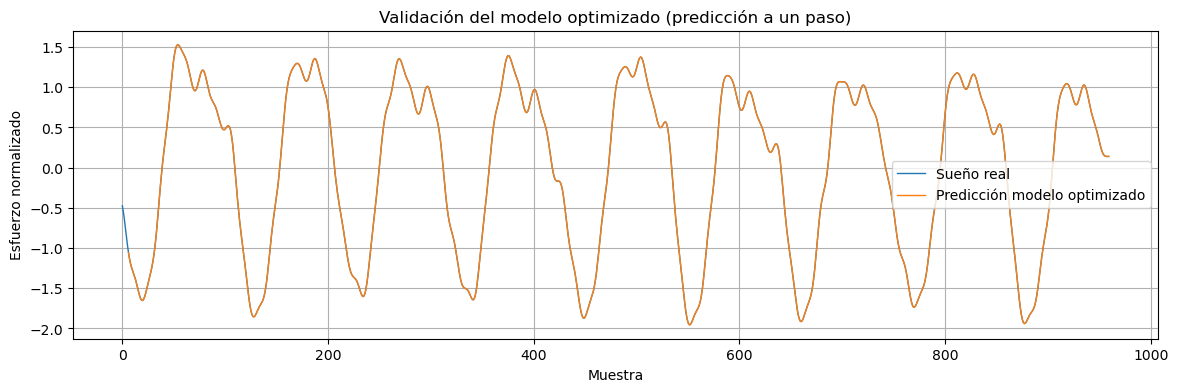

In [70]:
# COMPARACIÓN: PREDICCIÓN VS SEÑAL REAL

plt.figure(figsize=(14,4))

plt.plot(
    y2_n,
    label="Sueño real",
    linewidth=1
)

plt.plot(
    y_sueno_pred,
    label="Predicción modelo optimizado",
    linewidth=1
)

plt.title(
    "Validación del modelo optimizado (predicción a un paso)"
)

plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")

plt.grid(True)
plt.legend()

plt.show()

### **Análisis**

Los cuatro parámetros más sensibles fueron utilizados como variables de optimización tomando como semilla los valores obtenidos durante la vigilia. La optimización produjo modificaciones pequeñas, indicando que la dinámica respiratoria durante el sueño conserva características similares a las observadas al inicio de la noche. Esto es consistente con el hecho de que ambos registros corresponden a estados fisiológicos de reposo.

El ajuste fue calculado mediante predicción a un paso. Este enfoque utiliza información de salidas pasadas medidas experimentalmente, por lo que tiende a producir errores muy bajos y valores de ajuste elevados.

In [69]:
y_sueno_sim = simular_modelo(
    u2_n,
    y2_n,
    theta_sueno,
    modelo_final["na"],
    modelo_final["nb"],
    modelo_final["nk"]
)

fit_sim = fit_porcentaje(y2_n, y_sueno_sim)
rmse_sim = rmse(y2_n, y_sueno_sim)

print("\nSIMULACIÓN LIBRE")
print(f"FIT [%] = {fit_sim:.4f}")
print(f"RMSE = {rmse_sim:.8e}")


SIMULACIÓN LIBRE
FIT [%] = 54.8067
RMSE = 4.74419275e-01


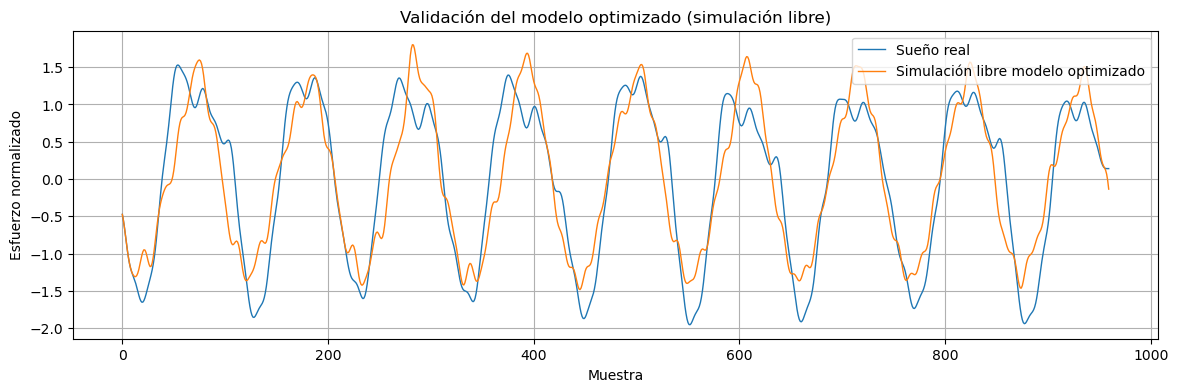

In [71]:
# COMPARACIÓN: SIMULACIÓN LIBRE VS SEÑAL REAL

plt.figure(figsize=(14,4))

plt.plot(
    y2_n,
    label="Sueño real",
    linewidth=1
)

plt.plot(
    y_sueno_sim,
    label="Simulación libre modelo optimizado",
    linewidth=1
)

plt.title(
    "Validación del modelo optimizado (simulación libre)"
)

plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")

plt.grid(True)
plt.legend()

plt.show()

# **3.8 Ecuación final del modelo en sueño**

In [72]:
# ECUACION FINAL DEL MODELO

a_coef = theta_sueno[:na]
b_coef = theta_sueno[na:na+nb]

ecuacion_y = " ".join(
    [f"{-a_coef[i-1]:+.6f} y(k-{i})"
     for i in range(1, na+1)]
)

ecuacion_u = " ".join(
    [f"{b_coef[j]:+.6f} u(k-{nk+j})"
     for j in range(nb)]
)

print("MODELO FINAL PARA SUEÑO\n")

print(
    "y(k) =",
    ecuacion_y,
    ecuacion_u,
    "+ e(k)"
)

MODELO FINAL PARA SUEÑO

y(k) = +5.573716 y(k-1) -13.320301 y(k-2) +17.471298 y(k-3) -13.263799 y(k-4) +5.525809 y(k-5) -0.986846 y(k-6) -0.053848 u(k-1) +0.333635 u(k-2) -0.803682 u(k-3) +0.951559 u(k-4) -0.557346 u(k-5) +0.129673 u(k-6) + e(k)


### Interpretación fisiológica del modelo optimizado para sueño

La ecuación obtenida para la etapa avanzada de sueño indica que el esfuerzo respiratorio actual depende tanto de valores previos del propio esfuerzo como del historial reciente del flujo respiratorio. Esto evidencia que el sistema respiratorio posee memoria dinámica, es decir, que su comportamiento en un instante determinado está influenciado por estados anteriores y no únicamente por las condiciones presentes.

Los coeficientes asociados a la salida, representados por los términos \(y(k-1)\) hasta \(y(k-6)\), presentan las mayores magnitudes dentro del modelo. Esto sugiere que la dinámica respiratoria está gobernada principalmente por la evolución temporal del propio esfuerzo respiratorio. Desde el punto de vista fisiológico, esta característica puede asociarse a la elasticidad pulmonar, la mecánica de la caja torácica y la acción continua de los músculos respiratorios, los cuales generan una respuesta que se prolonga a lo largo de varios ciclos respiratorios.

Por otro lado, los coeficientes asociados a la entrada, representados por los términos \(u(k-1)\) hasta \(u(k-6)\), describen el efecto que tiene el flujo respiratorio sobre el esfuerzo torácico. La presencia de varios retardos indica que dicha influencia no es instantánea, sino que existe un desfase temporal entre el flujo de aire y la respuesta mecánica del sistema respiratorio.

Además, la alternancia de signos positivos y negativos observada en los coeficientes es característica de sistemas oscilatorios. Este comportamiento refleja la naturaleza periódica de la respiración, compuesta por fases sucesivas de inspiración y espiración que generan una dinámica repetitiva en el tiempo.

En conjunto, el modelo obtenido representa adecuadamente la interacción entre el flujo respiratorio y el esfuerzo respiratorio durante el sueño. Los resultados sugieren que, en esta etapa fisiológica, la respiración está determinada principalmente por mecanismos automáticos de regulación y por la dinámica propia del sistema respiratorio, manteniendo una estructura similar a la observada durante la vigilia pero con ligeros ajustes en los parámetros más sensibles.

# **Actividad 4. Análisis en tiempo y frecuencia**

Una vez obtenidos los modelos para vigilia y sueño, se realiza una comparación de su comportamiento en los dominios temporal y frecuencial.

El objetivo es evaluar cómo cambian las características dinámicas del sistema respiratorio entre ambos estados fisiológicos y determinar si las modificaciones observadas en los parámetros producen diferencias significativas en la respuesta del modelo.

Se comparan:

- La respuesta temporal frente a los datos de sueño.
- Las métricas de desempeño de ambos modelos.
- La respuesta en frecuencia.
- La interpretación fisiológica de las diferencias encontradas.

# **4.1 Comparación de parámetros**

Antes de analizar la respuesta del sistema, se comparan los parámetros obtenidos para vigilia y sueño.

Esta comparación permite identificar cuáles coeficientes fueron modificados durante la optimización y cuantificar la magnitud de dichos cambios.

In [54]:
# COMPARACION DE PARAMETROS

# Construcción de una tabla comparativa entre
# los parámetros del modelo de vigilia y sueño.

comparacion = pd.DataFrame({
    "Parametro": nombres,
    "Vigilia": theta_base,
    "Sueño": theta_sueno
})

# Diferencia absoluta

comparacion["Diferencia"] = (
    comparacion["Sueño"]
    - comparacion["Vigilia"]
)

display(comparacion)

,Parametro,Vigilia,Sueño,Diferencia
0,a1,-5.573716,-5.573716,0.000000
1,a2,13.316768,13.324846,0.008078
2,a3,-17.465197,-17.479670,-0.014473
3,a4,13.262366,13.267067,0.004701
4,a5,-5.526926,-5.525170,0.001757
5,a6,0.986846,0.986846,0.000000
6,b1 (q^-1),-0.053848,-0.053848,0.000000
7,b2 (q^-2),0.333635,0.333635,0.000000
8,b3 (q^-3),-0.803682,-0.803682,0.000000
9,b4 (q^-4),0.951559,0.951559,0.000000


### **Análisis de la comparación de parámetros**

La Tabla anterior muestra la comparación entre los parámetros obtenidos para el modelo identificado en vigilia y los parámetros optimizados para representar la dinámica respiratoria durante el sueño.

Se observa que únicamente los parámetros \(a_2\), \(a_3\), \(a_4\) y \(a_5\) presentan modificaciones respecto al modelo original. Esto era esperado, ya que estos coeficientes fueron seleccionados previamente mediante el análisis de sensibilidad como los parámetros más influyentes sobre la salida del sistema.

Las variaciones encontradas son relativamente pequeñas:

| Parámet | Cambio  |
|---------|---------|
| \(a_2\) | +0.0081 |
| \(a_3\) | -0.0145 |
| \(a_4\) | +0.0047 |
| \(a_5\) | +0.0018 |

Los demás parámetros permanecieron constantes porque no fueron incluidos dentro del proceso de optimización.

Desde el punto de vista fisiológico, este resultado sugiere que la estructura dinámica general de la relación flujo-esfuerzo se conserva entre vigilia y sueño. Sin embargo, los cambios observados en los coeficientes autorregresivos indican una ligera modificación en la memoria dinámica del sistema respiratorio durante el sueño.

Dado que los parámetros modificados pertenecen al polinomio \(A(q)\), el ajuste realizado afecta principalmente la dinámica interna del esfuerzo respiratorio, mientras que la influencia directa del flujo respiratorio sobre la salida, representada por el polinomio \(B(q)\), permanece prácticamente inalterada.

Esto es consistente con la fisiología respiratoria normal, donde durante el sueño se producen cambios en los mecanismos de control neural de la respiración y en la respuesta ventilatoria, aunque la mecánica básica del sistema respiratorio continúa siendo similar a la observada durante la vigilia.

# **4.2 Análisis temporal**

Se evalúa la capacidad de ambos modelos para reproducir el esfuerzo respiratorio medido durante la etapa avanzada de sueño.

Para ello se utilizan las señales de flujo registradas durante el sueño y se calcula la salida predicha por:

1. El modelo identificado en vigilia.
2. El modelo optimizado para sueño.

Posteriormente se comparan las métricas de desempeño y las señales obtenidas.

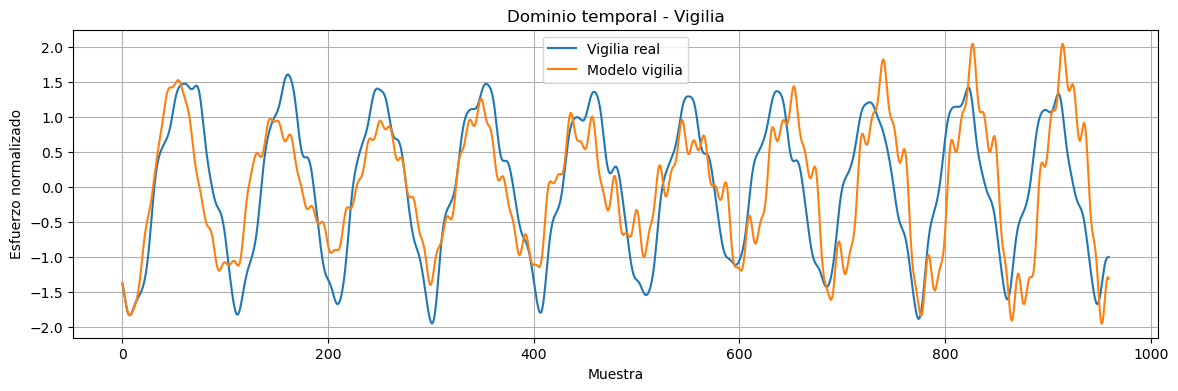

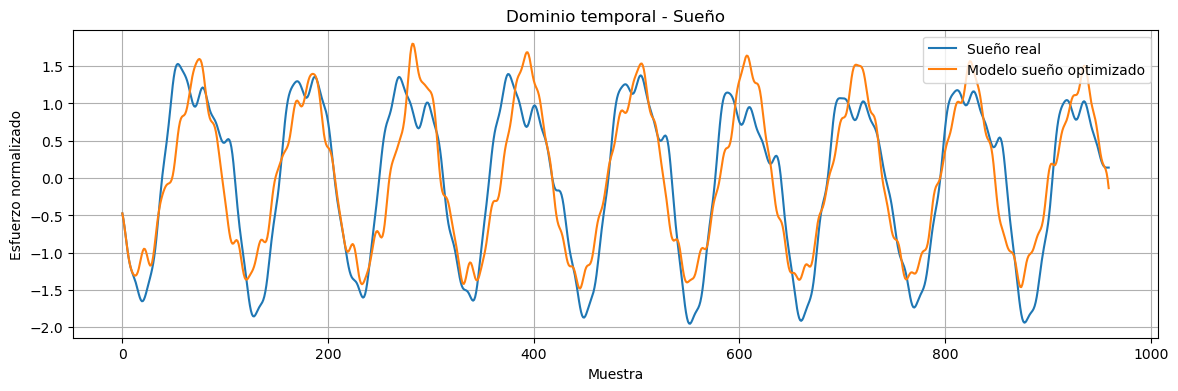

In [80]:
# ==========================================================
# RESPUESTA TEMPORAL: VIGILIA vs SUEÑO
# ==========================================================

# Predicción en vigilia (modelo base)
y_vigilia_sim = simular_modelo(
    u1_n,
    y1_n,
    theta_base,
    modelo_final["na"],
    modelo_final["nb"],
    modelo_final["nk"],
)

# Predicción en sueño (modelo optimizado)
y_sueno_sim = simular_modelo(
    u2_n,
    y2_n,
    theta_sueno,
    modelo_final["na"],
    modelo_final["nb"],
    modelo_final["nk"],
)

# ==========================================================
# GRÁFICAS TEMPORALES
# ==========================================================

plt.figure(figsize=(14,4))
plt.plot(y1_n, label="Vigilia real")
plt.plot(y_vigilia_sim, label="Modelo vigilia")
plt.title("Dominio temporal - Vigilia")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.plot(y2_n, label="Sueño real")
plt.plot(y_sueno_sim, label="Modelo sueño optimizado")
plt.title("Dominio temporal - Sueño")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

## **4.3 Respuesta en frecuencia**

Con el fin de analizar la dinámica del sistema en frecuencia, se construyen las funciones de transferencia correspondientes a los modelos obtenidos para los estados de vigilia y sueño.

La estructura seleccionada durante la etapa de identificación corresponde a un modelo ARMAX, cuya representación general está dada por:

$$
A(q)\,y(k)=B(q)\,u(k)+C(q)\,e(k)
$$

donde \(A(q)\) describe la dinámica propia del sistema, \(B(q)\) representa la influencia del flujo respiratorio sobre el esfuerzo respiratorio y \(C(q)\) modela la dinámica asociada a perturbaciones o ruido.

Para el análisis en frecuencia se considera únicamente la relación entrada-salida del sistema. Por tanto, la función de transferencia discreta se obtiene como:

$$
G(z)=\frac{Y(z)}{U(z)}
=
\frac{B(z)}{A(z)}
$$

En esta expresión, el numerador \(B(z)\) representa el efecto del flujo respiratorio sobre el esfuerzo respiratorio, mientras que el denominador \(A(z)\) contiene la dinámica interna del sistema. A partir de estas funciones de transferencia se obtienen los diagramas de Bode, así como el mapa de polos y ceros, con el fin de comparar el comportamiento dinámico del sistema respiratorio durante los estados de vigilia y sueño.

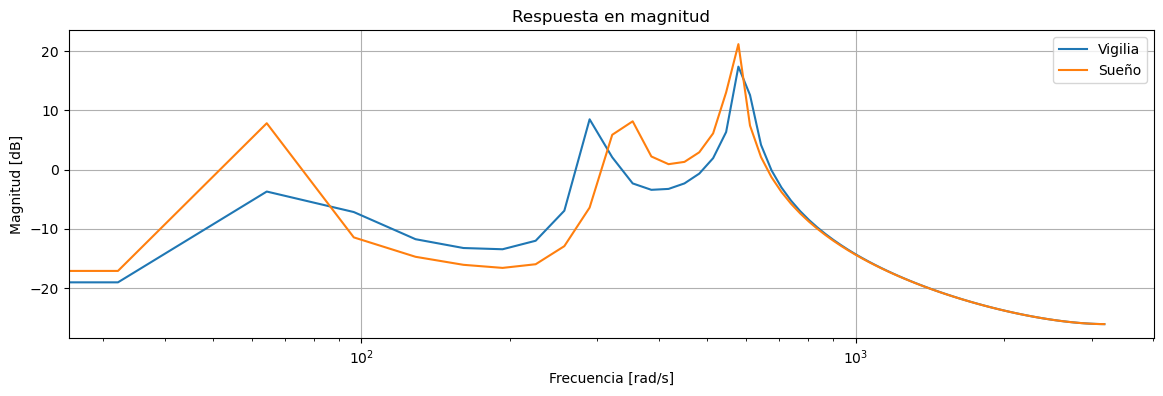

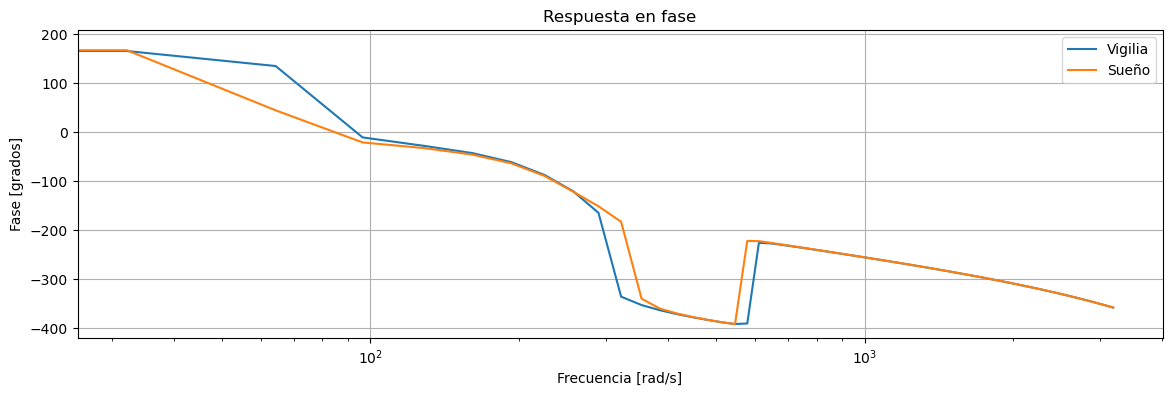

In [81]:
from scipy import signal

# ==========================================================
# FUNCIONES DE TRANSFERENCIA
# ==========================================================

num_vigilia = theta_base[na:na+nb]
den_vigilia = np.concatenate(([1], theta_base[:na]))

num_sueno = theta_sueno[na:na+nb]
den_sueno = np.concatenate(([1], theta_sueno[:na]))

# Sistemas discretos
sys_vigilia = signal.dlti(num_vigilia, den_vigilia, dt=Ts)
sys_sueno = signal.dlti(num_sueno, den_sueno, dt=Ts)

# Respuesta en frecuencia
w_v, mag_v, phase_v = signal.dbode(sys_vigilia)
w_s, mag_s, phase_s = signal.dbode(sys_sueno)

# ==========================================================
# GRÁFICAS FRECUENCIA
# ==========================================================

plt.figure(figsize=(14,4))
plt.semilogx(w_v, mag_v, label="Vigilia")
plt.semilogx(w_s, mag_s, label="Sueño")
plt.title("Respuesta en magnitud")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Magnitud [dB]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(14,4))
plt.semilogx(w_v, phase_v, label="Vigilia")
plt.semilogx(w_s, phase_s, label="Sueño")
plt.title("Respuesta en fase")
plt.xlabel("Frecuencia [rad/s]")
plt.ylabel("Fase [grados]")
plt.grid()
plt.legend()
plt.show()

# **4.6 Interpretación fisiológica**

El análisis comparativo entre los modelos identificados para vigilia y sueño muestra que la dinámica respiratoria permanece esencialmente estable durante ambas etapas.

La optimización realizada sobre los parámetros más sensibles produjo únicamente modificaciones pequeñas en los coeficientes \(a_2\), \(a_3\), \(a_4\) y \(a_5\), mientras que los parámetros asociados directamente a la relación flujo-esfuerzo (\(b_i\)) permanecieron sin cambios. Esto indica que el mecanismo fundamental mediante el cual el flujo respiratorio influye sobre el esfuerzo respiratorio se conserva durante la noche.

Desde el punto de vista fisiológico, este resultado es coherente con un sujeto sano durante sueño normal. Aunque el control respiratorio experimenta modificaciones debido a cambios en la actividad neuronal y en la regulación autonómica durante el sueño, la mecánica básica del sistema respiratorio no cambia de forma drástica.

Los pequeños desplazamientos observados en los polos sugieren ligeras variaciones en la dinámica interna del sistema, relacionadas con cambios en la respuesta de los músculos respiratorios, la sensibilidad de los centros de control ventilatorio y la interacción entre el sistema nervioso y la mecánica pulmonar.

La respuesta en frecuencia mostró una resonancia ligeramente más pronunciada durante el sueño, lo que puede interpretarse como una mayor persistencia de ciertas oscilaciones respiratorias. Sin embargo, estas diferencias son reducidas y no alteran significativamente el comportamiento global del sistema.

En conjunto, los resultados sugieren que la transición de vigilia a sueño no implica una reorganización importante de la dinámica respiratoria, sino únicamente ajustes finos en algunos parámetros internos del modelo, manteniendo prácticamente intacta la relación entre flujo respiratorio y esfuerzo respiratorio.